In [22]:
!pip install gym==0.26.2
!pip install pygame

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 11.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for gym: filename=gym-0.26.2-py3-none-any.whl size=827726 sha256=45767d1f13184653e5f3ed268a23f6b02b9316f8353b606cda37601dbf371486
  Stored in directory: /root/.cache/pip/wheels/95/51/6c/9bb05ebbe7c5cb8171dfaa3611f32622ca4658d53f31c79077
Successfully built gym
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [1]:
import gym
import numpy as np
import matplotlib.pyplot as plt
from time import sleep

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [14]:
env = gym.make('FrozenLake-v1') # is_slippery = True - by default, стохастичне середовище
print("Кількість станів:", env.observation_space.n)
print("Кількість дій:", env.action_space.n)

Кількість станів: 16
Кількість дій: 4


In [3]:
def show_render(img):
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [4]:
def compute_value_function(policy, gamma=1.0, theta=1e-10):
    """
    Обчислює функцію цінності V(s) для заданої політики policy.

    policy - масив, де для кожного стану записана дія
    gamma  - коефіцієнт дисконту
    theta  - поріг зупинки

    Повертає:
    value_table - масив цінностей станів
    """

    value_table = np.zeros(env.observation_space.n)

    while True:
        updated_value_table = np.copy(value_table)

        for state in range(env.observation_space.n):
            action = policy[state]
            value = 0

            # env.unwrapped.P[state][action] -> список переходів
            # кожен елемент: (probability, next_state, reward, done)
            for prob, next_state, reward, done in env.unwrapped.P[state][action]:
                value += prob * (reward + gamma * updated_value_table[next_state])

            value_table[state] = value

        # перевірка збіжності
        if np.sum(np.abs(updated_value_table - value_table)) <= theta:
            break

    return value_table

In [5]:
def extract_policy(value_table, gamma=1.0):
    """
    На основі value_table будує нову політику:
    для кожного стану вибирає дію з максимальним очікуваним значенням.
    """

    policy = np.zeros(env.observation_space.n, dtype=int)

    for state in range(env.observation_space.n):
        Q_table = np.zeros(env.action_space.n)

        for action in range(env.action_space.n):
            for prob, next_state, reward, done in env.unwrapped.P[state][action]:
                Q_table[action] += prob * (reward + gamma * value_table[next_state])

        policy[state] = np.argmax(Q_table)

    return policy

In [6]:
def policy_iteration(gamma=1.0):
    """
    Повертає:
    optimal_policy - оптимальну політику
    """

    # початкова політика: всюди дія 0
    policy = np.zeros(env.observation_space.n, dtype=int)

    while True:
        old_policy = np.copy(policy)

        # 1. Оцінка поточної політики
        value_function = compute_value_function(policy, gamma)

        # 2. Покращення політики
        policy = extract_policy(value_function, gamma)

        # 3. Якщо політика не змінилась - зупиняємось
        if np.array_equal(old_policy, policy):
            break

    return policy

In [7]:
optimal_policy = policy_iteration(gamma=1.0)
print("Оптимальна політика (у вигляді масиву):")
print(optimal_policy)

Оптимальна політика (у вигляді масиву):
[0 3 3 3 0 0 0 0 3 1 0 0 0 2 1 0]


In [8]:
print("Оптимальна політика у форматі 4x4:")
print(optimal_policy.reshape(4, 4))

Оптимальна політика у форматі 4x4:
[[0 3 3 3]
 [0 0 0 0]
 [3 1 0 0]
 [0 2 1 0]]


In [9]:
action_map = {
    0: '←',
    1: '↓',
    2: '→',
    3: '↑'
}

policy_symbols = np.array([action_map[action] for action in optimal_policy])
print("Оптимальна політика стрілками:")
print(policy_symbols.reshape(4, 4))

Оптимальна політика стрілками:
[['←' '↑' '↑' '↑']
 ['←' '←' '←' '←']
 ['↑' '↓' '←' '←']
 ['←' '→' '↓' '←']]


In [10]:
render_env = gym.make('FrozenLake-v1', render_mode='rgb_array')

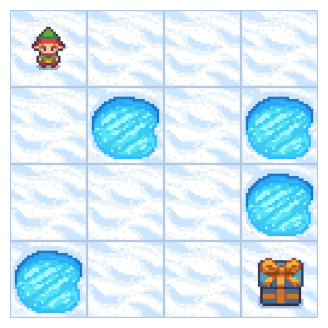

In [11]:
state, info = render_env.reset()
show_render(render_env.render())

Починаємо рух за оптимальною політикою...



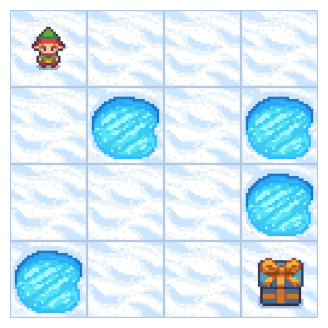

Крок 0: стан = 0, дія = ←


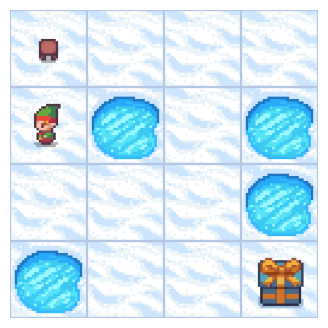

Крок 1: стан = 4, дія = ←


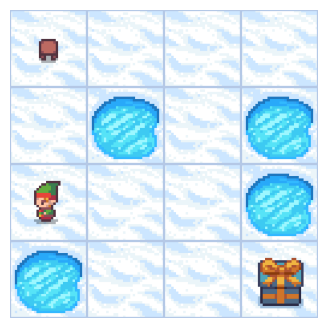

Крок 2: стан = 8, дія = ↑


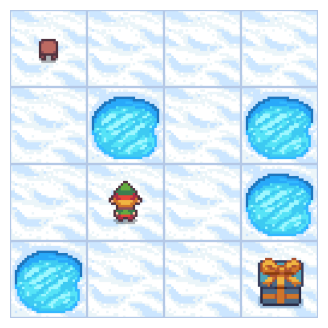

Крок 3: стан = 9, дія = ↓


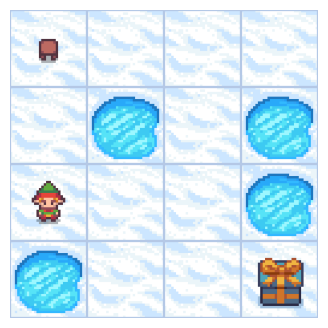

Крок 4: стан = 8, дія = ↑


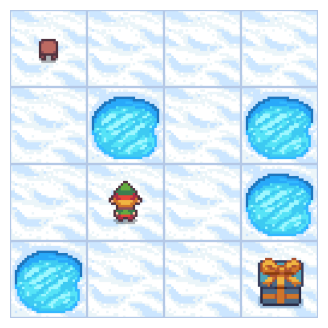

Крок 5: стан = 9, дія = ↓


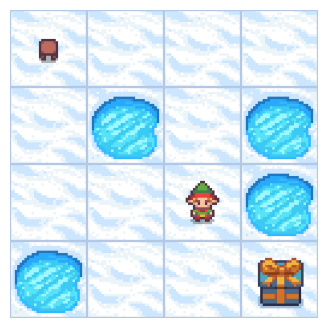

Крок 6: стан = 10, дія = ←


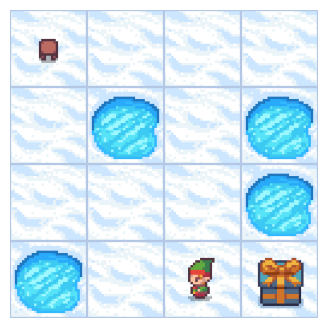

Крок 7: стан = 14, дія = ↓


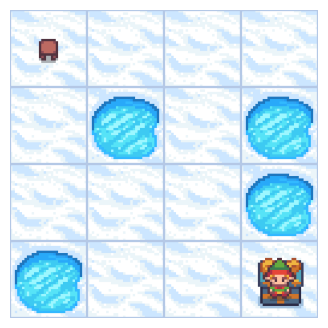

Завершено.
Фінальний стан: 15
Нагорода: 1.0


In [13]:
state, info = render_env.reset()
done = False
truncated = False

print("Починаємо рух за оптимальною політикою...\n")

step_num = 0
show_render(render_env.render())

while not done and not truncated:
    action = optimal_policy[state]
    print(f"Крок {step_num}: стан = {state}, дія = {action_map[action]}")

    state, reward, done, truncated, info = render_env.step(action)
    show_render(render_env.render())

    step_num += 1
    sleep(0.5)

print("Завершено.")
print("Фінальний стан:", state)
print("Нагорода:", reward)

**Висновок:**

У ході виконання завдання було завантажено середовище FrozenLake-v1 з бібліотеки OpenAI Gym. Було реалізовано функцію compute_value_function() для обчислення цінності станів при фіксованій політиці та функцію policy_iteration() для пошуку оптимальної політики методом ітерації за політиками. Після виконання алгоритму було отримано оптимальну політику для середовища FrozenLake. Також виконано візуалізацію руху агента за знайденою політикою за допомогою функції show_render(). Отриманий результат показує, що метод ітерації за політиками дозволяє знаходити ефективну стратегію дій у марковському середовищі.